# Logistic Regression

Input: `cleaned_startup_data.csv` (01 notebook se).

Steps: split -> scaling -> default model -> hyperparameter tuning -> results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

## 1. Data load

In [2]:
import os

# 01 notebook se bani hui file chahiye. Agar Colab me nahi mili to upload ka button aayega,
# wahan cleaned_startup_data.csv select karo
if not os.path.exists('/content/cleaned_startup_data.csv'):
    from google.colab import files
    files.upload()

df = pd.read_csv('/content/cleaned_startup_data.csv')
print(df.shape)
df.head()

(11787, 7)


,funding_rounds,target,funding_missing,founded_at_year,first_funding_at_year,last_funding_at_year,log_funding
0,1,1,0,2012.0,2015.0,2015.0,15.424949
1,1,1,0,2009.0,2009.0,2009.0,13.122365
2,2,1,0,2010.0,2010.0,2011.0,14.745705
3,2,1,0,2011.0,2011.0,2011.0,14.038655
4,1,1,0,2000.0,2010.0,2010.0,17.370859


## 2. Train test split

In [3]:
X = df.drop(columns=['target'])
y = df['target']

# 80% train, 20% test. stratify se dono me closed/acquired ka ratio same rehta hai
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Train:', X_train.shape)
print('Test :', X_test.shape)

Train: (9429, 6)
Test : (2358, 6)


## 3. Scaling

Logistic Regression ke liye features ko same scale pe lana zaroori hai (funding bahut bada number hai, year chhota). Scaler sirf train data pe fit karte hai, phir test pe lagate hai.

In [4]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 4. Default Logistic Regression

In [5]:
def get_scores(y_true, y_pred, y_prob):
    scores = {}
    scores['Accuracy'] = accuracy_score(y_true, y_pred)
    scores['Precision'] = precision_score(y_true, y_pred)
    scores['Recall'] = recall_score(y_true, y_pred)
    scores['F1'] = f1_score(y_true, y_pred)
    scores['ROC-AUC'] = roc_auc_score(y_true, y_prob)
    return scores

In [6]:
lr_default = LogisticRegression(max_iter=1000, random_state=42)
lr_default.fit(X_train_s, y_train)

pred_default = lr_default.predict(X_test_s)
prob_default = lr_default.predict_proba(X_test_s)[:, 1]

scores_default = get_scores(y_test, pred_default, prob_default)
for name, value in scores_default.items():
    print(name, ':', round(value, 4))

Accuracy : 0.6972
Precision : 0.6996
Recall : 0.6252
F1 : 0.6603
ROC-AUC : 0.7606


## 5. Hyperparameter tuning

- `C` : regularization ki strength (chhota C = zyada regularization)
- `penalty` : l1 ya l2
- `class_weight` : None ya balanced

GridSearchCV har combination ko 5-fold cross validation se check karta hai.

In [7]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(LogisticRegression(solver='liblinear', max_iter=1000, random_state=42),
                    param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train_s, y_train)

print('Best parameters:', grid.best_params_)
print('Best CV ROC-AUC:', round(grid.best_score_, 4))

Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2'}
Best CV ROC-AUC: 0.7551


In [8]:
lr_tuned = grid.best_estimator_

pred_tuned = lr_tuned.predict(X_test_s)
prob_tuned = lr_tuned.predict_proba(X_test_s)[:, 1]

scores_tuned = get_scores(y_test, pred_tuned, prob_tuned)
for name, value in scores_tuned.items():
    print(name, ':', round(value, 4))

Accuracy : 0.6925
Precision : 0.6771
Recall : 0.6631
F1 : 0.67
ROC-AUC : 0.7606


## 6. Comparison: default vs tuned

In [9]:
results = pd.DataFrame({'Default': scores_default, 'Tuned': scores_tuned}).T
results.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Default,0.6972,0.6996,0.6252,0.6603,0.7606
Tuned,0.6925,0.6771,0.6631,0.6700,0.7606


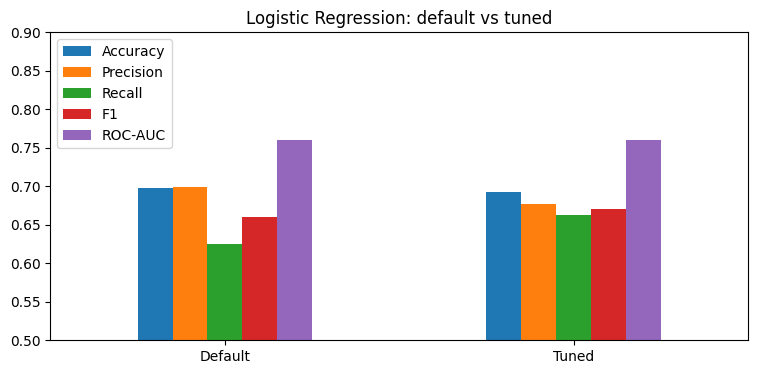

In [10]:
results.plot(kind='bar', figsize=(9, 4), ylim=(0.5, 0.9))
plt.title('Logistic Regression: default vs tuned')
plt.xticks(rotation=0)
plt.show()

## 7. Confusion matrix

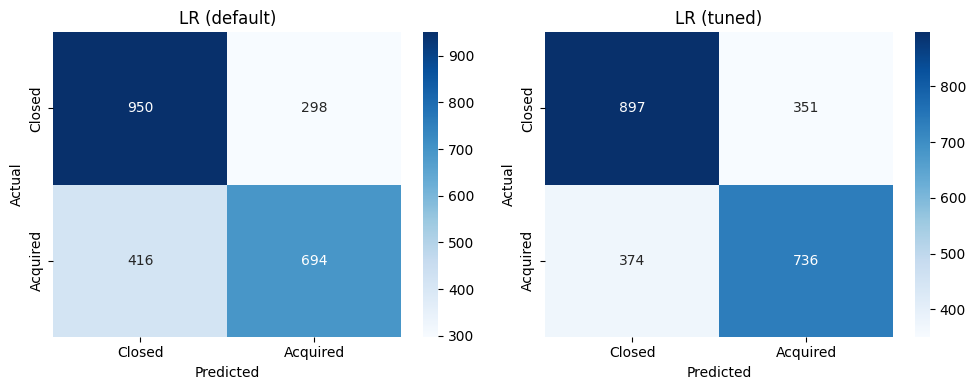

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(confusion_matrix(y_test, pred_default), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Closed', 'Acquired'], yticklabels=['Closed', 'Acquired'])
axes[0].set_title('LR (default)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, pred_tuned), annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Closed', 'Acquired'], yticklabels=['Closed', 'Acquired'])
axes[1].set_title('LR (tuned)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [12]:
print(classification_report(y_test, pred_tuned, target_names=['Closed', 'Acquired']))

              precision    recall  f1-score   support

      Closed       0.71      0.72      0.71      1248
    Acquired       0.68      0.66      0.67      1110

    accuracy                           0.69      2358
   macro avg       0.69      0.69      0.69      2358
weighted avg       0.69      0.69      0.69      2358



## 8. ROC curve

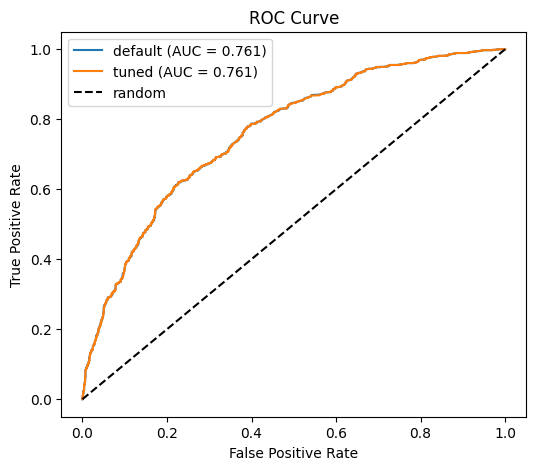

In [13]:
fpr1, tpr1, _ = roc_curve(y_test, prob_default)
fpr2, tpr2, _ = roc_curve(y_test, prob_tuned)

plt.figure(figsize=(6, 5))
plt.plot(fpr1, tpr1, label='default (AUC = %.3f)' % roc_auc_score(y_test, prob_default))
plt.plot(fpr2, tpr2, label='tuned (AUC = %.3f)' % roc_auc_score(y_test, prob_tuned))
plt.plot([0, 1], [0, 1], 'k--', label='random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 9. Kaun sa feature important hai?

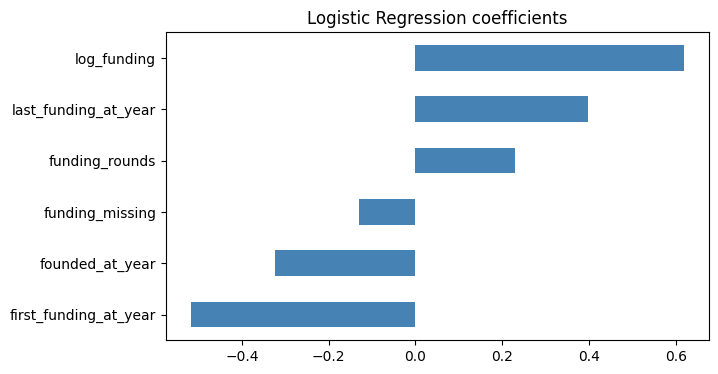

In [14]:
coef = pd.Series(lr_tuned.coef_[0], index=X.columns).sort_values()
coef.plot(kind='barh', figsize=(7, 4), color='steelblue')
plt.title('Logistic Regression coefficients')
plt.show()

Positive coefficient = acquired hone ka chance badhata hai, negative = kam karta hai.

## 10. Train vs test accuracy

In [15]:
print('Train accuracy:', round(lr_tuned.score(X_train_s, y_train), 4))
print('Test accuracy :', round(lr_tuned.score(X_test_s, y_test), 4))

Train accuracy: 0.6885
Test accuracy : 0.6925


## Conclusion

- Tuned model ke test results: Accuracy 0.6925, Precision 0.6771, Recall 0.6631, F1 0.6700, ROC-AUC 0.7606.
- Tuning se ROC-AUC same raha (0.7606). Best C = 1 hi nikla, jo default value hai. `class_weight='balanced'` se recall badha (0.625 se 0.663), lekin accuracy aur precision thodi kam hui.
- Train accuracy (0.689) aur test accuracy (0.693) almost same hai, yaani overfitting nahi hai. Lekin accuracy 70% ke paas hi atki hai, kyunki Logistic Regression sirf seedhe (linear) relation pakad paata hai aur features sirf 6 hai.